In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.calibration import CalibrationDisplay

str_dirname_output = './output'
os.makedirs(str_dirname_output, exist_ok=True)

## Load XGBoost Results

In [2]:
df_xgb = pd.read_csv('../03_xgboost/output/df_tuning.csv')
df_xgb_preds = pd.read_csv('../03_xgboost/output/test_predictions.csv')

## Load Logistic Regression Results

In [3]:
df_log = pd.read_csv('../04_logistic_regression/output/df_tuning.csv')
df_log_preds = pd.read_csv('../04_logistic_regression/output/test_predictions.csv')

## Head-to-Head Comparison

In [4]:
list_dict_row = []
for col in ['flt_roc_auc_train','flt_roc_auc_valid','flt_roc_auc_test','flt_pr_auc_train','flt_pr_auc_valid','flt_pr_auc_test']:
    flt_metric_xgb = df_xgb[col].iloc[0]
    flt_metric_log = df_log[col].iloc[0]
    dict_row = {
        'metric': col,
        'xgb': flt_metric_xgb,
        'log': flt_metric_log
    }
    list_dict_row.append(dict_row)
df = pd.DataFrame(list_dict_row)
df['pct_diff'] = (df['xgb'] - df['log']) / df['log']
df

,metric,xgb,log,pct_diff
0,flt_roc_auc_train,0.826669,0.774213,0.067754
1,flt_roc_auc_valid,0.800995,0.759743,0.054297
2,flt_roc_auc_test,0.799937,0.757805,0.055597
3,flt_pr_auc_train,0.548643,0.413541,0.326697
4,flt_pr_auc_valid,0.497295,0.397472,0.251144
5,flt_pr_auc_test,0.497111,0.394923,0.258755


## Grouped Bar Chart: Metrics Comparison

## Conclusion

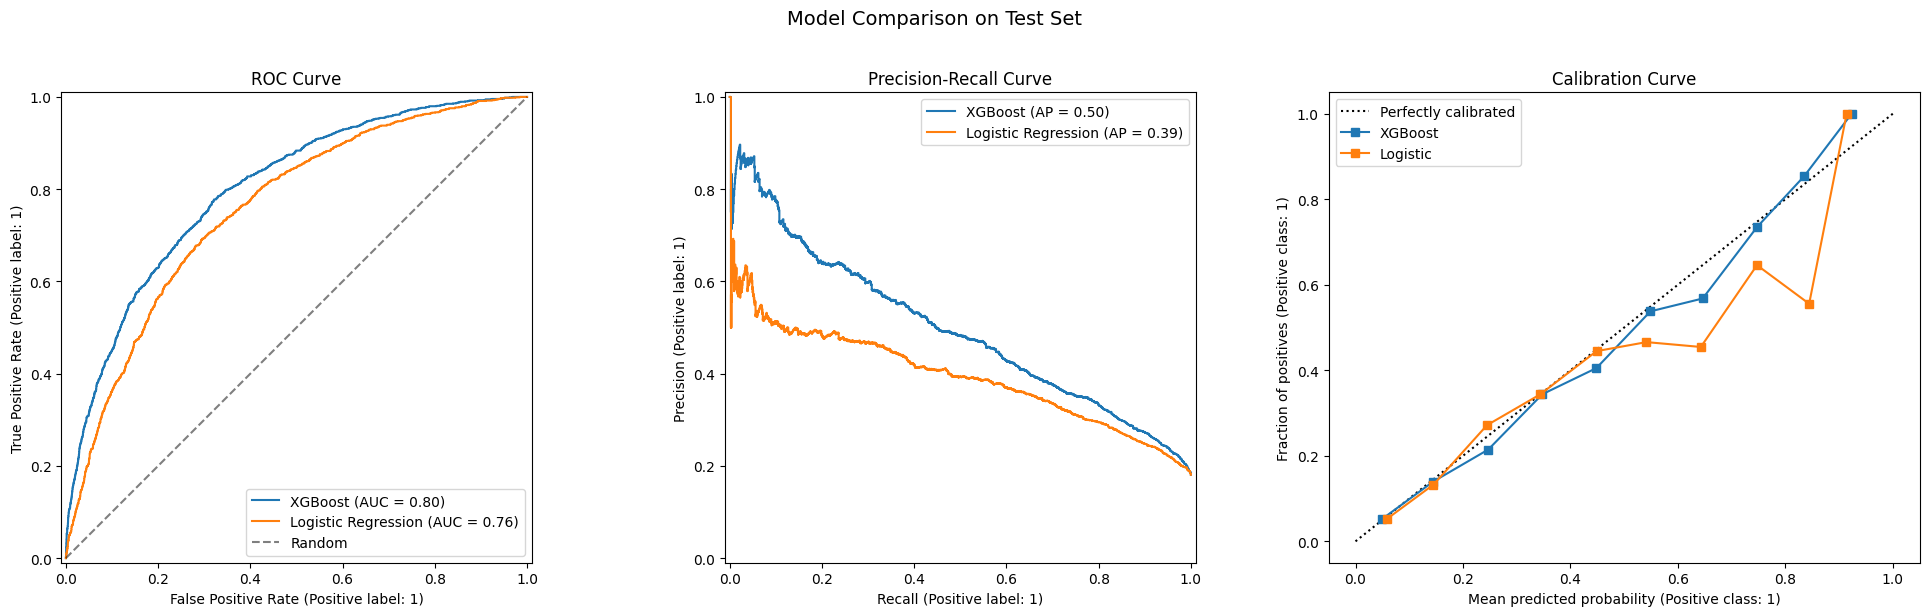

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Model Comparison on Test Set', fontsize=14, y=1.02)

# ROC Curve Comparison
RocCurveDisplay.from_predictions(
    df_xgb_preds['y_test'], df_xgb_preds['y_hat_test'], name='XGBoost', ax=axes[0])
RocCurveDisplay.from_predictions(
    df_log_preds['y_test'], df_log_preds['y_hat_test'], name='Logistic Regression', ax=axes[0])
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')

# Precision-Recall Curve Comparison
PrecisionRecallDisplay.from_predictions(
    df_xgb_preds['y_test'], df_xgb_preds['y_hat_test'], name='XGBoost', ax=axes[1])
PrecisionRecallDisplay.from_predictions(
    df_log_preds['y_test'], df_log_preds['y_hat_test'], name='Logistic Regression', ax=axes[1])
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='upper right')

# Calibration Curve Comparison
CalibrationDisplay.from_predictions(
    df_xgb_preds['y_test'], df_xgb_preds['y_hat_test_calibrated'], n_bins=10, name='XGBoost', ax=axes[2])
CalibrationDisplay.from_predictions(
    df_log_preds['y_test'], df_log_preds['y_hat_test_calibrated'], n_bins=10, name='Logistic', ax=axes[2])
axes[2].set_title('Calibration Curve')
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.savefig(f'{str_dirname_output}/model_comparison_curves.png', bbox_inches='tight', dpi=150)
plt.show()

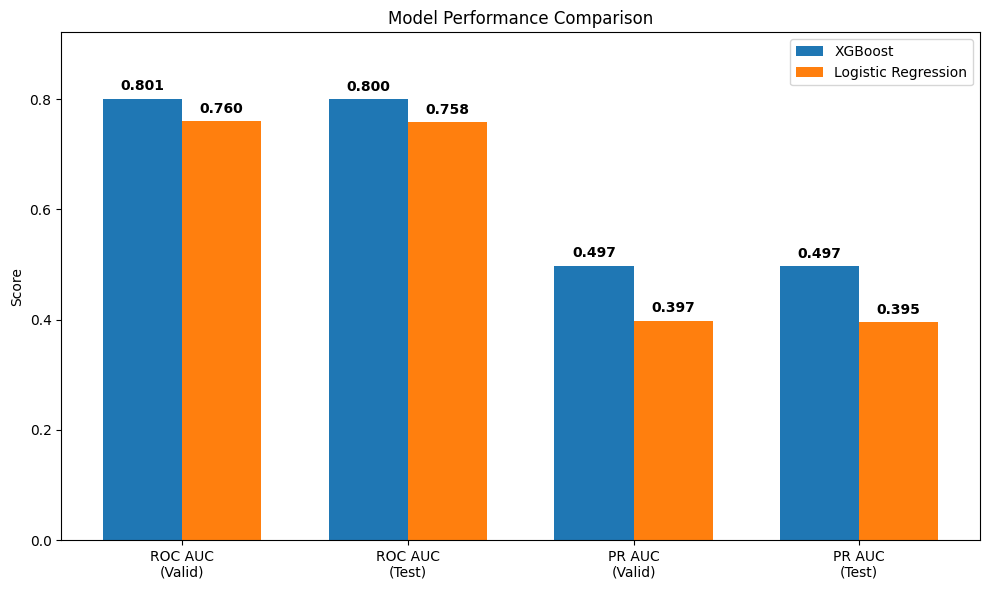

In [6]:
labels = ['ROC AUC\n(Valid)', 'ROC AUC\n(Test)', 'PR AUC\n(Valid)', 'PR AUC\n(Test)']
xgb_vals = [df_xgb['flt_roc_auc_valid'].iloc[0], df_xgb['flt_roc_auc_test'].iloc[0],
            df_xgb['flt_pr_auc_valid'].iloc[0], df_xgb['flt_pr_auc_test'].iloc[0]]
log_vals = [df_log['flt_roc_auc_valid'].iloc[0], df_log['flt_roc_auc_test'].iloc[0],
            df_log['flt_pr_auc_valid'].iloc[0], df_log['flt_pr_auc_test'].iloc[0]]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, xgb_vals, width, label='XGBoost', color='tab:blue')
bars2 = ax.bar(x + width/2, log_vals, width, label='Logistic Regression', color='tab:orange')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, max(max(xgb_vals), max(log_vals)) * 1.15)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{str_dirname_output}/metrics_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

## ROC, Precision-Recall, and Calibration Comparison (Test Set)

In [7]:
str_summary = """
XGBoost materially outperforms logistic regression across all evaluation metrics.
On ROC AUC, XGB delivers roughly a 5–6% relative improvement on validation and test sets, indicating stronger overall ranking performance. 
The improvement is even more pronounced for PR AUC, where XGB achieves approximately 24–26% relative lift on validation and test, 
which is especially meaningful given the 19% bad rate.

These results suggest that XGBoost is capturing nonlinear relationships and feature interactions that logistic regression cannot, 
leading to substantially better identification of positive cases while maintaining stable generalization from validation to test.

XGBoost is the champion!
"""
print(str_summary)


XGBoost materially outperforms logistic regression across all evaluation metrics.
On ROC AUC, XGB delivers roughly a 5–6% relative improvement on validation and test sets, indicating stronger overall ranking performance. 
The improvement is even more pronounced for PR AUC, where XGB achieves approximately 24–26% relative lift on validation and test, 
which is especially meaningful given the 19% bad rate.

These results suggest that XGBoost is capturing nonlinear relationships and feature interactions that logistic regression cannot, 
leading to substantially better identification of positive cases while maintaining stable generalization from validation to test.

XGBoost is the champion!

